Import LIbraries

In [1]:
%matplotlib inline

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Sequence

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


Global Pathes

In [2]:
_cwd = Path.cwd()
if (_cwd / "models").is_dir() and (_cwd / "metrics").is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "models").is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

MODEL_PATH = PROJECT_ROOT / "models" / "language_detector.joblib"
METRICS_DIR = PROJECT_ROOT / "metrics"
CM_CSV_PATH = METRICS_DIR / "language_detector.confusion_matrix.csv"
CM_PNG_PATH = CM_CSV_PATH.with_suffix(".png")

print("Project root:", PROJECT_ROOT)
print("Model path:", MODEL_PATH)


Project root: /home/magdy/magdy/NLP/Project/lang_detection
Model path: /home/magdy/magdy/NLP/Project/lang_detection/models/language_detector.joblib


In [3]:
def build_model() -> Pipeline:
    features = FeatureUnion(
        [
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 6),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=300_000,
                ),
            ),
            (
                "char_wb",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 7),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=200_000,
                ),
            ),
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=200_000,
                ),
            ),
        ],
        n_jobs=1,
    )
    clf = LinearSVC(C=3.0)
    return Pipeline([("features", features), ("clf", clf)])


def save_confusion_matrix_png(cm, labels: List[str], path: Path) -> None:
    import matplotlib.pyplot as plt

    n = len(labels)
    size = max(10.0, n * 0.35)
    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title("Language detection — confusion matrix (test)")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=90, ha="right", fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Load dataset

In [4]:
from datasets import load_dataset

dataset = load_dataset("papluca/language-identification")

x_train = list(dataset["train"]["text"])
y_train = list(dataset["train"]["labels"])
x_test = list(dataset["test"]["text"])
y_test = list(dataset["test"]["labels"])

print("Train size:", len(x_train))
print("Test size:", len(x_test))

pd.DataFrame({"text": x_train[:5], "label": y_train[:5]})

/home/magdy/anaconda3/envs/iti/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train size: 70000
Test size: 10000


,text,label
0,"os chefes de defesa da estónia, letónia, lituâ...",pt
1,размерът на хоризонталната мрежа може да бъде ...,bg
2,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,zh
3,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,th
4,Он увеличил давление .,ru


## Train and evaluate

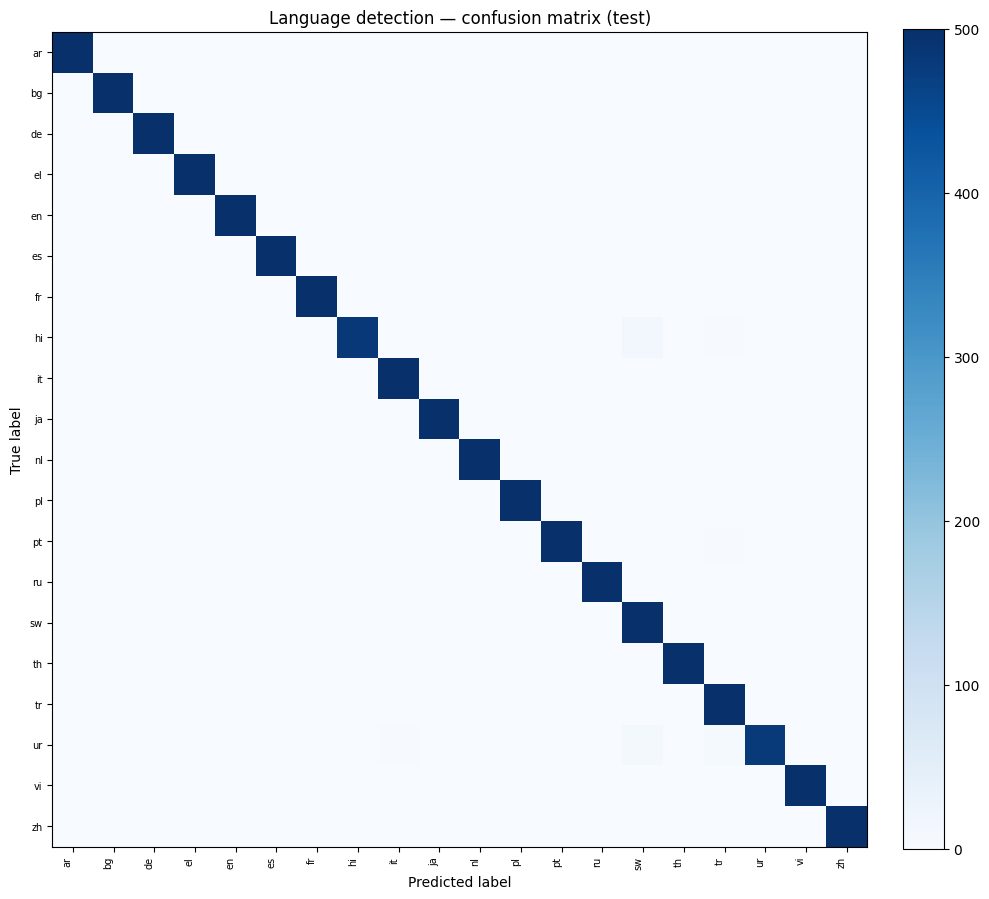

Test accuracy: 0.9956
Saved model -> /home/magdy/magdy/NLP/Project/lang_detection/models/language_detector.joblib
Saved confusion matrix -> /home/magdy/magdy/NLP/Project/lang_detection/metrics/language_detector.confusion_matrix.csv
Saved confusion matrix plot -> /home/magdy/magdy/NLP/Project/lang_detection/metrics/language_detector.confusion_matrix.png

              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9980    1.0000    0.9990       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9980    1.0000    0.9990       500
          es     1.0000    0.9980    0.9990       500
          fr     0.9980    1.0000    0.9990       500
          hi     1.0000    0.9680    0.9837       500
          it     0.9920    0.9960    0.9940       500
          ja     1.0000    1.0000    1.0000       500
          nl     0.9980    1.0000    0.9990      

In [ ]:
model = build_model()
model.fit(x_train, y_train)

preds = model.predict(x_test)
test_accuracy = accuracy_score(y_test, preds)
report = classification_report(y_test, preds, digits=4)

labels = sorted(set(y_test) | set(preds))
cm = confusion_matrix(y_test, preds, labels=labels)

METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame(cm, index=labels, columns=labels).to_csv(CM_CSV_PATH)
save_confusion_matrix_png(cm, labels, CM_PNG_PATH)
joblib.dump(model, MODEL_PATH)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Saved model -> {MODEL_PATH}")
print(f"Saved confusion matrix -> {CM_CSV_PATH}")
print(f"Saved confusion matrix plot -> {CM_PNG_PATH}")
print()
print(report)